In [1]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import os
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("✅ Entorno de ejecución listo. TensorFlow versión:", tf.__version__)

✅ Entorno de ejecución listo. TensorFlow versión: 2.20.0


In [2]:
# ==============================================================================
# 2. AUTENTICACIÓN Y DESCARGA AUTOMÁTICA DEL DATASET (API KAGGLE)
# ==============================================================================
# Configuración segura de credenciales de la API de Kaggle (Plan B Manual)
os.environ['KAGGLE_USERNAME'] = "sam1g1"
os.environ['KAGGLE_KEY'] = "KGAT_f6da358a8110c35edf1b7a20fe5cd5eb"

# Descarga directa del repositorio paquetizado
print("📥 Descargando noise-audio-data desde Kaggle...")
!kaggle datasets download -d javohirtoshqorgonov/noise-audio-data

# Descompresión silenciosa en el directorio raíz
print("📦 Descomprimiendo archivos...")
!unzip -q noise-audio-data.zip

print("✅ Dataset listo y disponible en el directorio raíz de Colab.")

📥 Descargando noise-audio-data desde Kaggle...
Dataset URL: https://www.kaggle.com/datasets/javohirtoshqorgonov/noise-audio-data
License(s): unknown
100% 616M/616M [00:37<00:00, 17.3MB/s]

📦 Descomprimiendo archivos...
✅ Dataset listo y disponible en el directorio raíz de Colab.


In [3]:
# ==============================================================================
# 3. EXTRACCIÓN DE CARACTERÍSTICAS ESPECTRALES (ESPECTROGRAMAS MEL)
# ==============================================================================
def preparar_audio(ruta_archivo):
    """
    Carga una señal de audio, extrae su Espectrograma Mel y normaliza
    sus dimensiones espaciales para la entrada de la red convolucional.
    """
    # Carga del audio limitando la ventana temporal a 5 segundos para uniformidad
    audio, sr = librosa.load(ruta_archivo, duration=5)

    # Extracción del Espectrograma Mel usando 128 bandas de frecuencia
    espectrograma = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)

    # Conversión a escala logarítmica (Decibelios) para maximizar el contraste de armónicos
    log_espectrograma = librosa.power_to_db(espectrograma, ref=np.max)

    # Ajuste dimensional estricto (Padding/Truncado) a un estándar de 128x216 píxeles
    if log_espectrograma.shape[1] < 216:
        log_espectrograma = np.pad(log_espectrograma, ((0,0), (0, 216 - log_espectrograma.shape[1])))
    else:
        log_espectrograma = log_espectrograma[:, :216]

    return log_espectrograma

print("⚙️ Pipeline matemático de preprocesamiento configurado con éxito.")

⚙️ Pipeline matemático de preprocesamiento configurado con éxito.


In [4]:
# ==============================================================================
# 4. FILTRADO DE CLASES CLIMÁTICAS/FLUVIALES Y CONSTRUCCIÓN DE DATASETS
# ==============================================================================
# Lectura del archivo de metadatos estructurado
df = pd.read_csv('ESC-50-master/meta/esc50.csv')

# Aislamiento de clases objetivo para el entorno acuático del Río Magdalena
clases_naturales = ['rain', 'river', 'water_drops', 'wind']
clases_motores = ['engine', 'helicopter']

# Extracción del subconjunto balanceado
df_filtrado = df[df['category'].isin(clases_naturales + clases_motores)].copy()

# Etiquetado binario: 0 = Silencio Biológico / 1 = Ruido Antropogénico (Motores)
df_filtrado['label'] = df_filtrado['category'].apply(lambda x: 1 if x in clases_motores else 0)

X = []
y = []

print("⏳ Extrayendo espectrogramas mel mediante buscador recursivo...")

for index, row in df_filtrado.iterrows():
    nombre_archivo = row['filename']
    # Mitigación de inconsistencias en las rutas del sistema de archivos mediante glob
    archivos_encontrados = glob.glob(f"**/{nombre_archivo}", recursive=True)

    if len(archivos_encontrados) > 0:
        ruta_real = archivos_encontrados[0]
        foto_sonido = preparar_audio(ruta_real)
        X.append(foto_sonido)
        y.append(row['label'])

# Formateo de tensores multidimensionales (Muestras, Alto, Ancho, Canales)
X = np.array(X).reshape(-1, 128, 216, 1)
y = np.array(y)

print(f"\n📊 Distribución de datos consolidada:")
print(f"-> Tensor de entrada X: {X.shape}")
print(f"-> Tensor de etiquetas y: {y.shape}")
print(df_filtrado.groupby('category').size())

⏳ Extrayendo espectrogramas mel mediante buscador recursivo...

📊 Distribución de datos consolidada:
-> Tensor de entrada X: (200, 128, 216, 1)
-> Tensor de etiquetas y: (200,)
category
engine         40
helicopter     40
rain           40
water_drops    40
wind           40
dtype: int64


In [5]:
# ==============================================================================
# 5. ARQUITECTURA DE LA RED NEURONAL CONVOLUCIONAL (CNN) REGULARIZADA
# ==============================================================================
def crear_modelo_blindado():
    model = models.Sequential([
        layers.Input(shape=(128, 216, 1)),

        # Bloque Convolucional 1: Extracción morfológica inicial
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(), # Estabilización de activaciones intra-capa
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2), # Control de sobreajuste temprano

        # Bloque Convolucional 2: Análisis espectral intermedio
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Bloque Convolucional 3: Ritmos y micro-frecuencias complejas
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Clasificador Densamente Conectado (Fully Connected)
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5), # Penalización estricta a la memorización de ruido

        # Capa de salida binaria probabilística
        layers.Dense(2, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

mi_ia_blindada = crear_modelo_blindado()
mi_ia_blindada.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 216, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 55296)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,078,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,172,354 (27.36 MB)

 Trainable params: 7,171,650 (27.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [6]:
# ==============================================================================
# 6. OPTIMIZACIÓN Y ENTRENAMIENTO DE ALTA FIDELIDAD
# ==============================================================================
print("🚀 Iniciando el entrenamiento del modelo regularizado...")

# Se extienden las épocas a 30 para compensar la alta tasa de desincorporación (Dropout)
historia_blindada = mi_ia_blindada.fit(X, y, epochs=30, batch_size=16, validation_split=0.2)

print("\n🎉 Proceso de optimización en lote completado.")

🚀 Iniciando el entrenamiento del modelo regularizado...
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.6438 - loss: 1.1908 - val_accuracy: 0.6000 - val_loss: 11.7157
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7375 - loss: 0.6249 - val_accuracy: 0.6000 - val_loss: 2.3062
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7250 - loss: 0.6388 - val_accuracy: 0.6000 - val_loss: 4.1821
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7437 - loss: 0.6164 - val_accuracy: 0.6000 - val_loss: 4.8605
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8188 - loss: 0.4016 - val_accuracy: 0.6000 - val_loss: 3.6997
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8188 - loss: 0.4916 - val_accuracy: 0.6000 - val_loss: 2.8192
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8313 - loss: 0.3979 - val_accuracy: 0.6000 - val_loss: 2.7664
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step -

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step


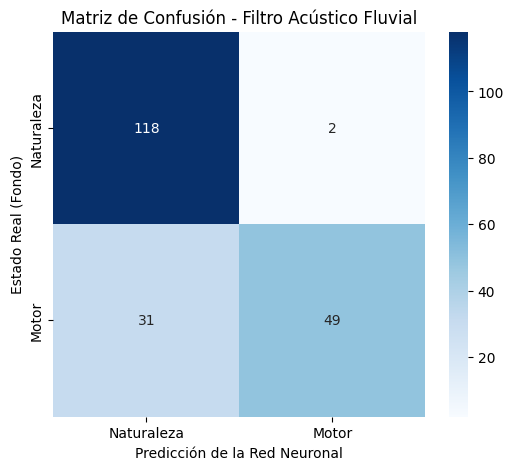


📋 Reporte Estadístico Riguroso:
              precision    recall  f1-score   support

  Naturaleza       0.79      0.98      0.88       120
       Motor       0.96      0.61      0.75        80

    accuracy                           0.83       200
   macro avg       0.88      0.80      0.81       200
weighted avg       0.86      0.83      0.83       200



In [7]:
# ==============================================================================
# 7. EVALUACIÓN DE DESEMPEÑO (ANÁLISIS DE FALSOS POSITIVOS Y NEGATIVOS)
# ==============================================================================
# Predicciones probabilísticas del modelo
predicciones = mi_ia_blindada.predict(X)
y_pred = np.argmax(predicciones, axis=1)

# Cálculo de la matriz empírica
cm = confusion_matrix(y, y_pred)

# Graficación mediante mapas de calor estéticos (Seaborn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Naturaleza', 'Motor'],
            yticklabels=['Naturaleza', 'Motor'])
plt.ylabel('Estado Real (Fondo)')
plt.xlabel('Predicción de la Red Neuronal')
plt.title('Matriz de Confusión - Filtro Acústico Fluvial')
plt.show()

# Despliegue de métricas de precisión, sensibilidad y F1-Score
print("\n📋 Reporte Estadístico Riguroso:")
print(classification_report(y, y_pred, target_names=['Naturaleza', 'Motor']))

In [ ]:
# ==============================================================================
# 8. EXPORTACIÓN Y OPTIMIZACIÓN A FORMATO COMPACTO (TENSORFLOW LITE)
# ==============================================================================
print("📦 Compilando modelo para optimización en hardware...")

# Conversión del grafo de Keras a un binario optimizado para baja potencia computacional
converter = tf.lite.TFLiteConverter.from_keras_model(mi_ia_blindada)
tflite_model = converter.convert()

# Almacenamiento en disco local del entorno
with open('ROV.tflite', 'wb') as f:
    f.write(tflite_model)

print("💾 Archivo 'ROV.tflite' exportado con éxito.")
print("Listo para integración en microcontroladores, Raspberry Pi o computación perimetral (Edge).")

📦 Compilando modelo para optimización en hardware...
Saved artifact at '/tmp/tmpzwlekfpn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 216, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135458809948752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809948368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809951248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809951440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809950096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809950672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809952208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809952016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809950864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458809949136: TensorSpec(sha